In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

directory = '.'
files = [f for f in os.listdir(directory) if f.endswith('.xlsx') and f[:-5].isdigit()]
dfs = []
for file in files:
    df = pd.read_excel(os.path.join(directory, file), decimal=',', thousands='.')
    year = file.split('.')[0]
    df['ano'] = int(year)
    dfs.append(df)
combined_df = pd.concat(dfs, ignore_index=True)
df = combined_df
if 'populacao_nacional' in df.columns:
    df = df.drop('populacao_nacional', axis=1)

ibge_path = '../../../dados/IBGE/populacao_PNAD.xlsx'
proj_path = '../../../dados/IBGE/projecao_2025.xlsx'

if os.path.exists(ibge_path):
    df_ibge = pd.read_excel(ibge_path)
    df_ibge_long = pd.melt(
        df_ibge,
        id_vars=['Cód.', 'Unidade da Federação'],
        value_vars=[2019, 2020, 2021, 2022, 2023, 2024],
        var_name='ano', value_name='populacao_uf'
    )
else:
    df_ibge_long = pd.DataFrame()

if os.path.exists(proj_path):
    df_proj_2025 = pd.read_excel(proj_path)
    df_proj_2025 = df_proj_2025.rename(columns={'total': 'populacao_uf'})
    df_proj_2025['ano'] = 2025
    df_ibge_long = pd.concat([df_ibge_long, df_proj_2025], ignore_index=True)

if not df_ibge_long.empty:
    df_ibge_long = df_ibge_long.rename(columns={
        'Cód.': 'cod_uf',
        'Unidade da Federação': 'nome_uf'
    })

    df_ibge_long['ano'] = df_ibge_long['ano'].astype(int)

    mask_ate_2024 = df_ibge_long['ano'] <= 2024
    df_ibge_long.loc[mask_ate_2024, 'populacao_uf'] = df_ibge_long.loc[mask_ate_2024, 'populacao_uf'] * 1000

    national_pop = df_ibge_long.groupby('ano')['populacao_uf'].sum().reset_index()
    national_pop = national_pop.rename(columns={'populacao_uf': 'populacao_nacional'})

    df['ano'] = df['ano'].astype(int)
    df_with_pop = pd.merge(df, national_pop, on='ano', how='left')
    df = df_with_pop
else:
    pass

if 'populacao_nacional' not in df.columns:
    df['populacao_nacional'] = 100000

df.head()

/Users/juliasbardelatti/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,Brasil,Acomp. Domiciliados/Acamados,Acomp. Pessoa c/ Diabetes,Acomp. Pessoa c/ Hanseníase,Acomp. Pessoa c/ Tuberculose,Acomp. Pessoas c/ D. Crônicas,Acomp. Recém-nascido,Acomp. - DPOC/Enfisema,Acomp. - Usuário de drogas,Acomp. Cond. Bolsa Família,...,Busca ativa - Vacina,Cadastramento/Atualização,Controle de Ambientes/Vetores,Convite At.Col./Camp. Saúde,Egresso de Internação,Orientação / Prevenção,Outros,Visita periódica,ano,populacao_nacional
0,Nacional,3753263,12522276,88740,86665,6474484,6399,300239,69252,187723,...,9811315,11110041,7,4696144,235426,61720184,23010407,34097674,2021,100000
1,Nacional,2987868,10227283,47639,42591,5317134,4795,268189,59251,150385,...,3592516,8136826,7086,3499379,175516,44907457,15521892,30394710,2020,100000
2,Nacional,3740733,13046980,56270,44673,6608054,8904,316647,64893,208069,...,5058078,17281885,0,6068290,248240,67709986,27659199,30856508,2025,100000
3,Nacional,5786283,20457256,76151,66991,10307860,4060,470426,90441,324571,...,6473121,21576298,1,8998220,395121,103773890,42668226,48587170,2024,100000
4,Nacional,3142548,10820405,59060,53867,5271577,10508,295773,55071,176410,...,1985523,5861750,52961,5267345,205016,42329057,14282999,37002589,2019,100000


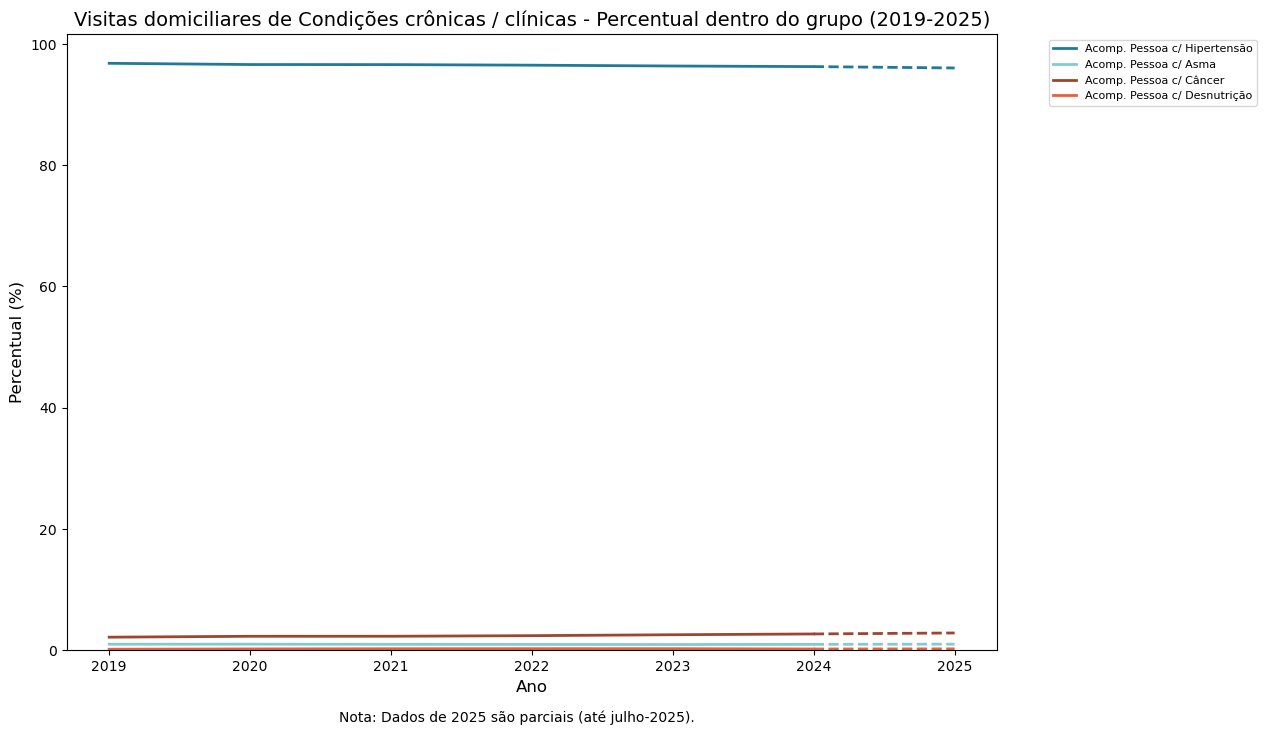

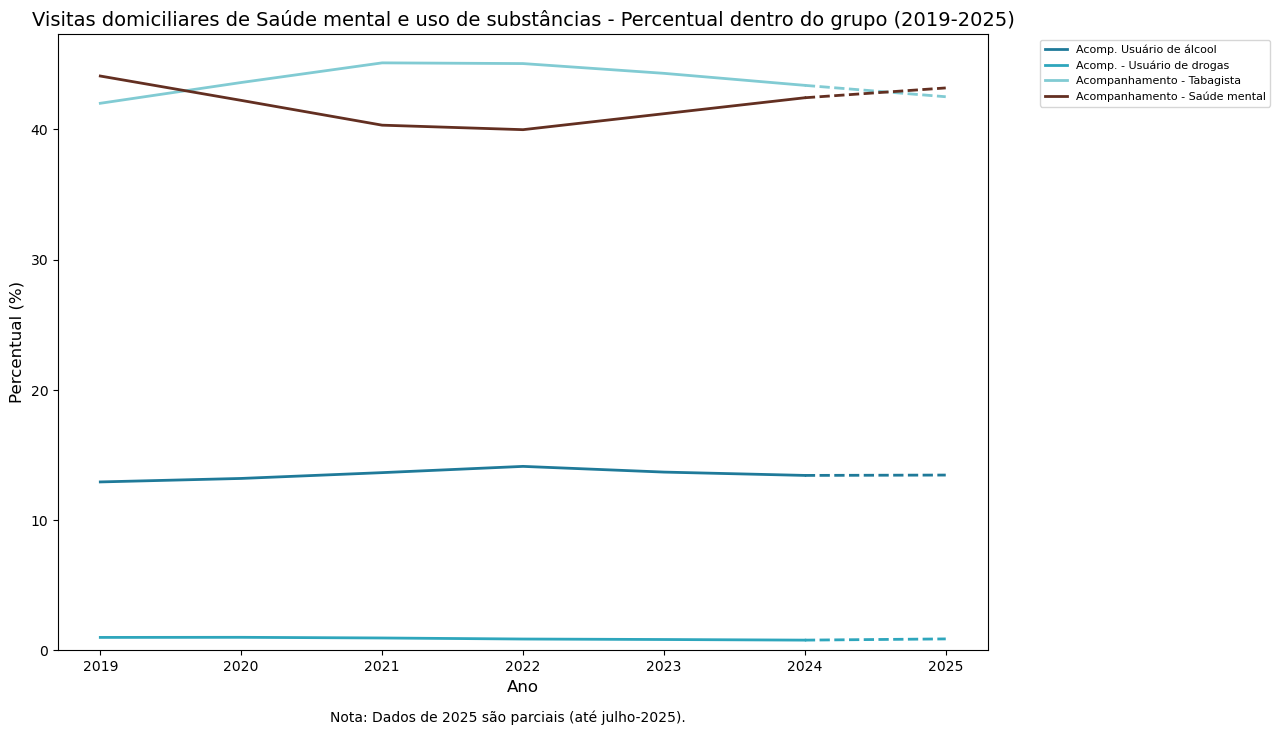

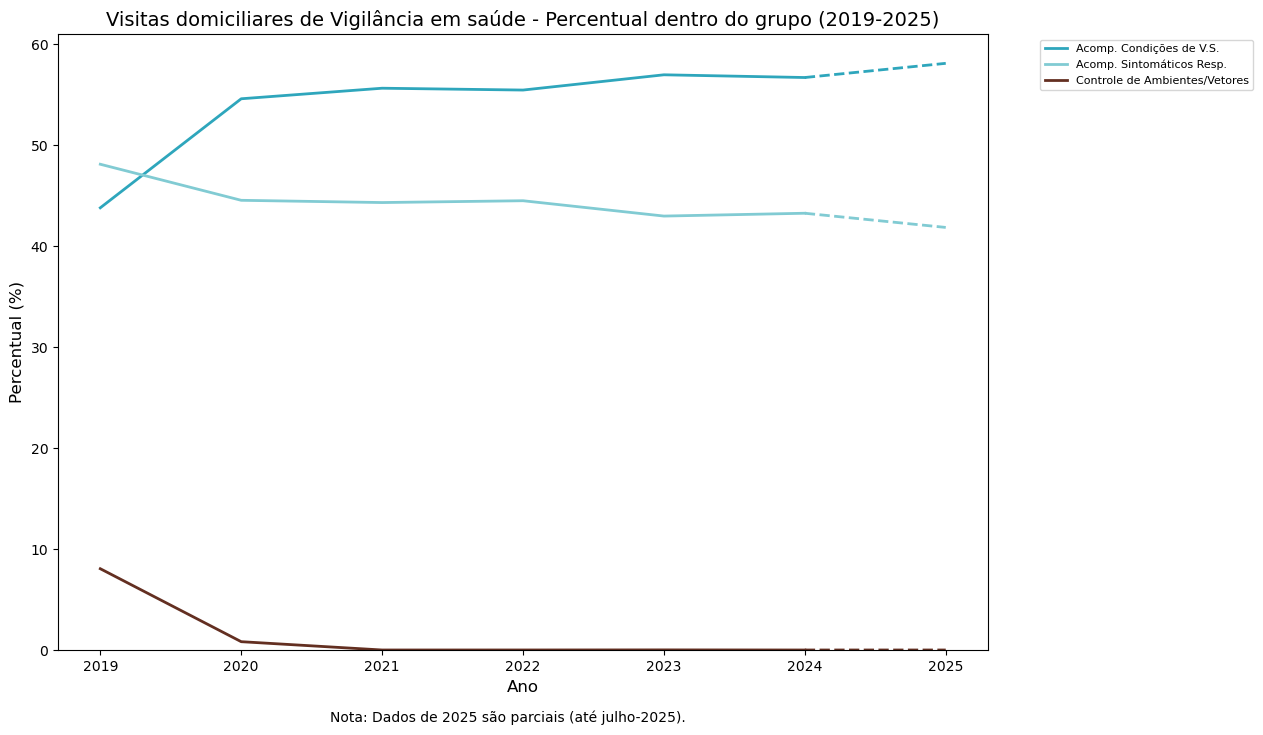

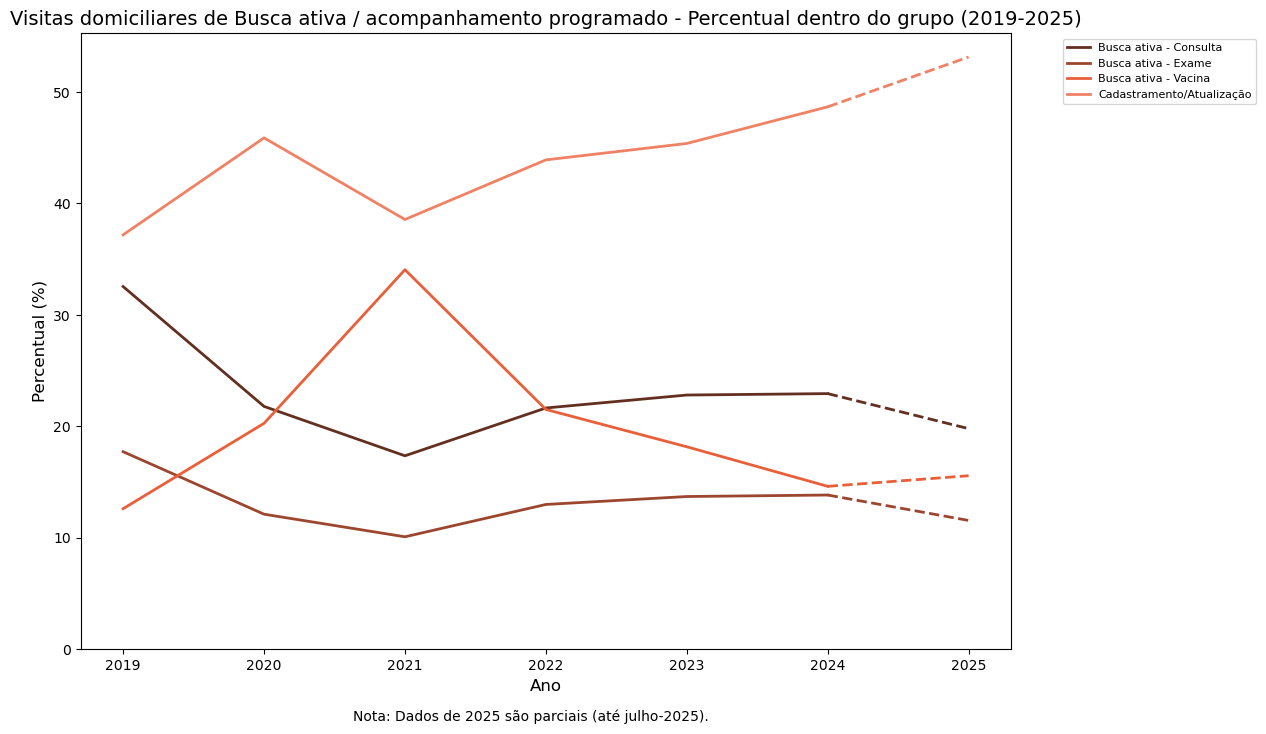

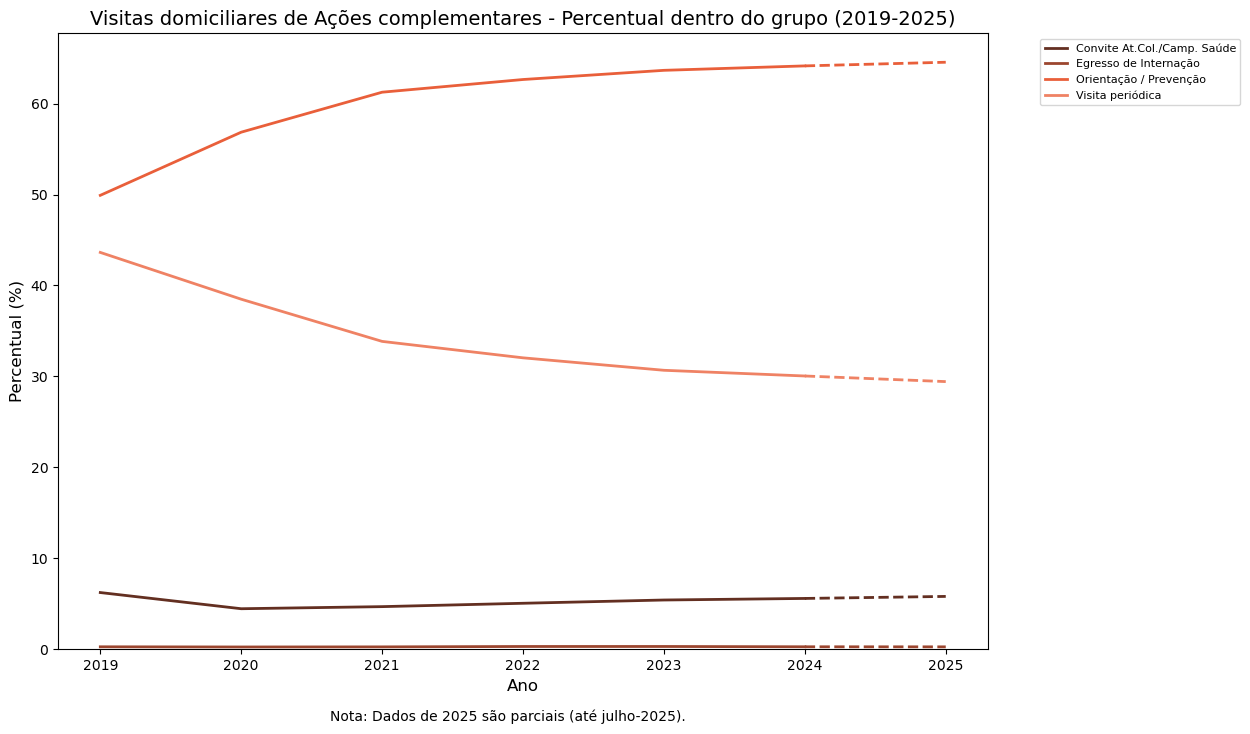

In [2]:
numeric_cols = [col for col in df.columns if col not in ['Brasil', 'ano', 'populacao_nacional']]

groups = {
    'Condições crônicas / clínicas': [
        'Acomp. Pessoa c/ Diabetes', 'Acomp. Pessoa c/ Hipertensão', 'Acomp. Pessoas c/ D. Crônicas',
        'Acomp. Pessoa c/ Asma', 'Acomp. - DPOC/Enfisema', 'Acomp. Pessoa c/ Câncer', 'Acomp. Pessoa c/ Desnutrição'
    ],
    'Saúde mental e uso de substâncias': [
        'Acomp. Usuário de álcool', 'Acomp. - Usuário de drogas', 'Acompanhamento - Tabagista', 'Acompanhamento - Saúde mental'
    ],
    'Vigilância em saúde': [
        'Acomp. Condições de V.S.', 'Acomp. Sintomáticos Resp.', 'Controle de Ambientes/Vetores'
    ],
    'Busca ativa / acompanhamento programado': [
        'B.A. - Cond. Bolsa Família', 'Busca ativa - Consulta', 'Busca ativa - Exame',
        'Busca ativa - Vacina', 'Cadastramento/Atualização'
    ],
    'Ações complementares': [
        'Convite At.Col./Camp. Saúde', 'Egresso de Internação', 'Orientação / Prevenção', 'Visita periódica'
    ]
}

df_melted = df.melt(id_vars=['ano', 'populacao_nacional'], value_vars=numeric_cols, var_name='tipo_visita', value_name='visitas')

for group_name, tipos in groups.items():
    for ano in df['ano'].unique():
        data_year = df_melted[(df_melted['ano'] == ano) & (df_melted['tipo_visita'].isin(tipos))]
        total_group = data_year['visitas'].sum()
        if total_group > 0:
            for tipo in tipos:
                if tipo in data_year['tipo_visita'].values:
                    visits = data_year[data_year['tipo_visita'] == tipo]['visitas'].values[0]
                    perc = (visits / total_group) * 100
                    df_melted.loc[(df_melted['ano'] == ano) & (df_melted['tipo_visita'] == tipo), 'percentual_grupo'] = perc
                else:
                    df_melted.loc[(df_melted['ano'] == ano) & (df_melted['tipo_visita'] == tipo), 'percentual_grupo'] = 0
        else:
            for tipo in tipos:
                df_melted.loc[(df_melted['ano'] == ano) & (df_melted['tipo_visita'] == tipo), 'percentual_grupo'] = 0

cat_colors = ["#114354", "#1F7A99", "#2EA6BC", "#81CBD3",
              "#632F21", "#9C462F", "#E95F3A", "#EF8264"]

for group_idx, (group_name, tipos) in enumerate(groups.items()):
    plt.figure(figsize=(12, 8))

    for i, tipo in enumerate(tipos):
        if tipo in df_melted['tipo_visita'].unique():
            color = cat_colors[(i + group_idx) % len(cat_colors)]
            data_tipo = df_melted[df_melted['tipo_visita'] == tipo].sort_values('ano')
            data_solid = data_tipo[data_tipo['ano'] <= 2024]
            plt.plot(data_solid['ano'], data_solid['percentual_grupo'], linestyle='-', color=color, label=tipo, linewidth=2)
            if 2024 in data_tipo['ano'].values and 2025 in data_tipo['ano'].values:
                val_2024 = data_tipo[data_tipo['ano'] == 2024]['percentual_grupo'].values[0]
                val_2025 = data_tipo[data_tipo['ano'] == 2025]['percentual_grupo'].values[0]
                plt.plot([2024, 2025], [val_2024, val_2025], linestyle='--', color=color, linewidth=2)

    plt.title(f'Visitas domiciliares de {group_name} - Percentual dentro do grupo (2019-2025)', fontsize=14)
    plt.xlabel('Ano', fontsize=12)
    plt.ylabel('Percentual (%)', fontsize=12)
    plt.ylim(bottom=0)
    plt.xticks(sorted(df['ano'].unique()))
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.figtext(0.5, 0.02, 'Nota: Dados de 2025 são parciais (até julho-2025).', ha='center', fontsize=10)
    plt.show()